# Demystifying Model Behavior: From Simple Genetics to Complex Epistasis

Welcome to this interactive notebook! In this space, we are going to explore exactly how machine learning models and explainability tools behave when we shift the underlying "ground truth" of categorical data. 

In the real world of genomics and bioinformatics, we often feed discrete data (like genotypes coded as 0, 1, and 2) into an algorithm like XGBoost and hope it finds the true biological patterns. But how do we know *what* the model is actually learning? To answer this, we are going to play the role of the "Creator." We will generate synthetic datasets where **we know the exact biological mechanisms** governing the target trait (y). 

By knowing the absolute, indisputable truth, we can test how well Traditional Statistics (OLS) and Machine Learning (XGBoost + SHAP) uncover that truth across three increasingly realistic biological scenarios.

## The Three Scenarios We Will Explore

We will run an end-to-end analytical pipeline—training, evaluating, and explaining—on the following three cases:

### Case 1: The Mendelian World (Pure Main Effects)
* **The Reality:** The target y is driven by independent genes acting alone. These genes might have an additive effect (a straight line from 0 to 2), a dominant effect (having one copy is the same as having two), or a recessive effect (you need both copies to see the trait).
* **The Goal:** Establish a baseline. We will see how traditional OLS handles standard additive traits perfectly, but might slightly misinterpret purely dominant or recessive traits, while XGBoost captures the exact categorical steps. 

### Case 2: The Complex Biological World (Epistatic Interactions)
* **The Reality:** Genes do not act in a vacuum; they interact with one another to influence the target (e.g., Gene A only turns on if Gene B is also present, known as epistasis). 
* **The Goal:** Observe the divergence between traditional stats and machine learning. OLS will struggle to see the gene-gene interaction without manual feature engineering, while XGBoost's tree structure will naturally map the combination. We will use SHAP interaction values to crack open the model and visualize exactly how these genes are working together.

### Case 3: The Incomplete World (Missing Heritability / Hidden Features)
* **The Reality:** We generate a complex dataset with interactions, but deliberately *hide* critical contributing genes from the model. 
* **The Goal:** Mimic messy, real-world clinical scenarios where we simply lack all the necessary genetic sequencing or environmental data. We will watch our evaluation metrics (like R-squared and MSE) degrade, and use SHAP to see how the model tries (and often fails) to compensate for the missing puzzle pieces.

## Our Toolkit
To accomplish this, we will be utilizing:
* **Custom Generators:** `numpy` and `pandas` to build the exact biological equations and categorical genotypes.
* **Baseline Modeling:** `statsmodels` (OLS) for traditional statistical significance and coefficient mapping.
* **Predictive Modeling:** `xgboost` to natively handle categorical data and capture non-linear step functions and complex interactions.
* **Explainability:** `shap` (SHapley Additive exPlanations) to trace global feature importance, visualize specific biological distributions via violin plots, and isolate pure variable interactions.

In [1]:
from XAI_test_2 import *

## simple linear combination test

### make example data 1

In [2]:
# 1. Generate Data
X, _, y, visible_features, _ = generate_synthetic_data_with_hidden_features(
    num_inputs=10, 
    num_samples=5000, 
    num_contributing_features=(3, 5), 
    num_hidden_features=(0, 0), 
    weight_range=(-3, 3), 
    num_interactions=(0, 0), 
    interaction_weight_range=(-3, 3), 
    noise_std=0.1, 
    hidden_in_linear=False,           
    hidden_in_interactions=False,
)
# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Generative Model Info (With HIDDEN Features) ---
y = 
  (-1.40 * Feature_8 [recessive]) + 
  (1.00 * Feature_7 [additive]) + 
  (0.63 * Feature_5 [recessive]) 
  + Noise(0, 0.1)



### make the Traditional Baseline (OLS)


--- Traditional Regression Analysis (OLS) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     2437.
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:28:27   Log-Likelihood:                -149.06
No. Observations:                4000   AIC:                             320.1
Df Residuals:                    3989   BIC:                             389.4
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

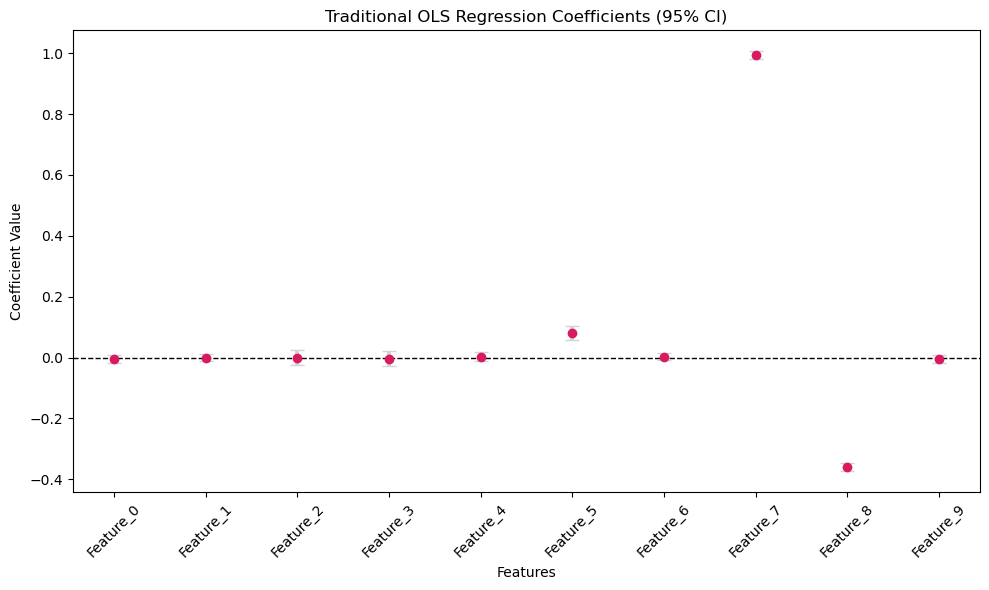

In [3]:

# 2. Traditional Baseline (OLS)
perform_traditional_regression(X_train, y_train)


### make a simple xgboost model for test 1

In [4]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost)
model = xgb.XGBRegressor(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1 Evaluation & XGBoost Importances
evaluate_xgb_model(model, X_test_cat, y_test)

--- XGBoost Performance (Testing) ---
R2 Score: 0.9779
MSE: 0.0109



### look at XGBoost Native Importances

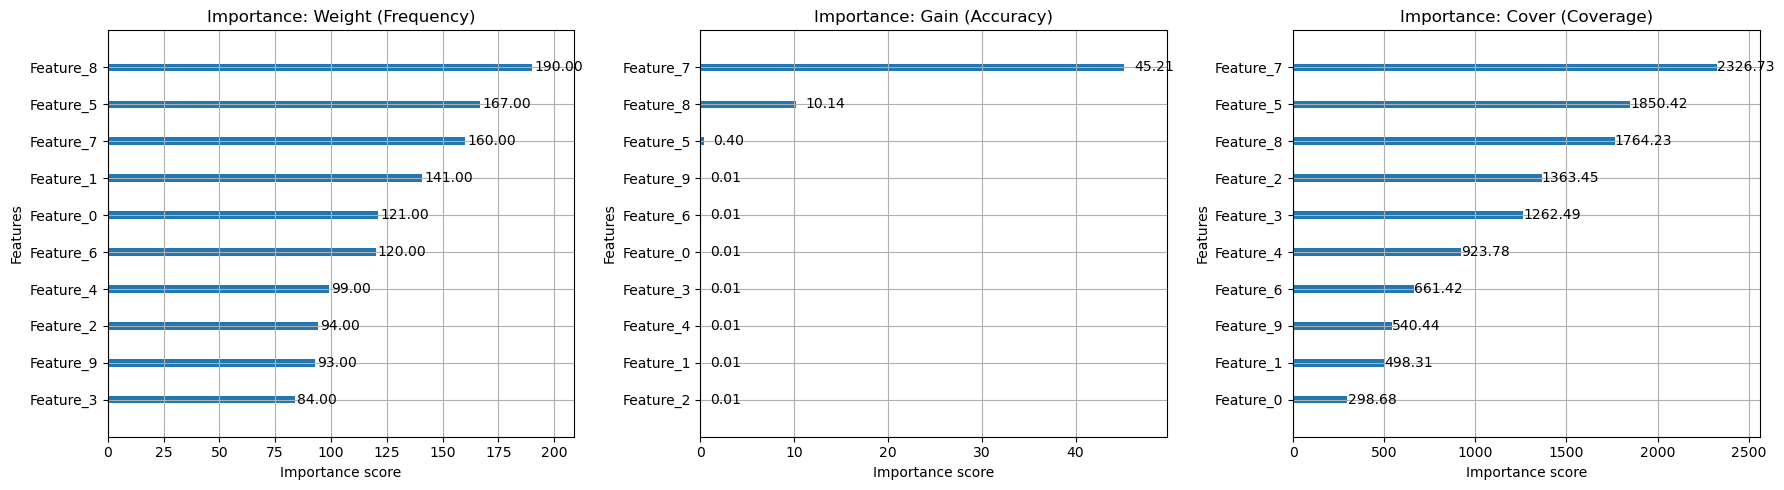

In [5]:

# 5.2 XGBoost Importances
plot_all_xgb_importances(model)


### try to use SHAP to find the influencing inputs

In [6]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

In [7]:

# Print numerical ranking
print_feature_importance(shap_values)



--- SHAP Feature Importance Ranking ---
SHAP Global Importance Dictionary:
  Feature_7: 0.5051
  Feature_8: 0.1433
  Feature_5: 0.0069
  Feature_6: 0.0019
  Feature_4: 0.0016
  Feature_2: 0.0016
  Feature_1: 0.0016
  Feature_9: 0.0013
  Feature_3: 0.0011
  Feature_0: 0.0010

Ranked Features (Most to Least Important):
['Feature_7', 'Feature_8', 'Feature_5', 'Feature_6', 'Feature_4', 'Feature_2', 'Feature_1', 'Feature_9', 'Feature_3', 'Feature_0']
---------------------------------------



['Feature_7',
 'Feature_8',
 'Feature_5',
 'Feature_6',
 'Feature_4',
 'Feature_2',
 'Feature_1',
 'Feature_9',
 'Feature_3',
 'Feature_0']

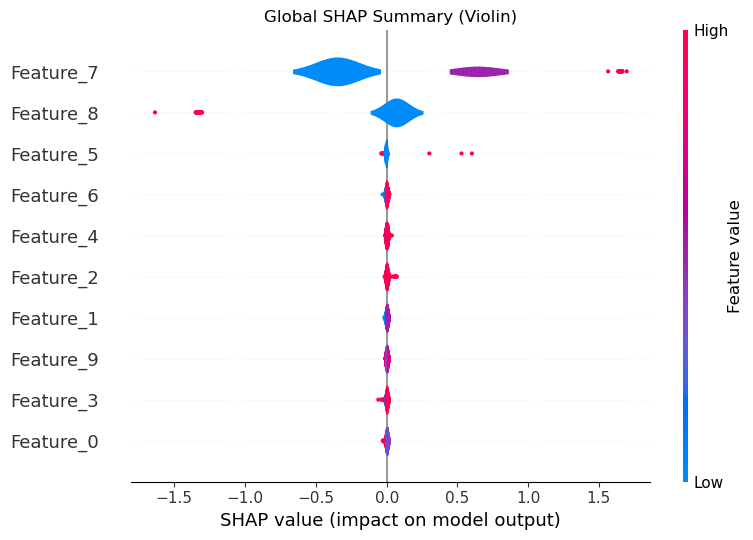

In [8]:

# Global SHAP Violin Summary
plot_shap_summary_violin(shap_values, X_test_cat)


Generating SHAP violin grid for all features...


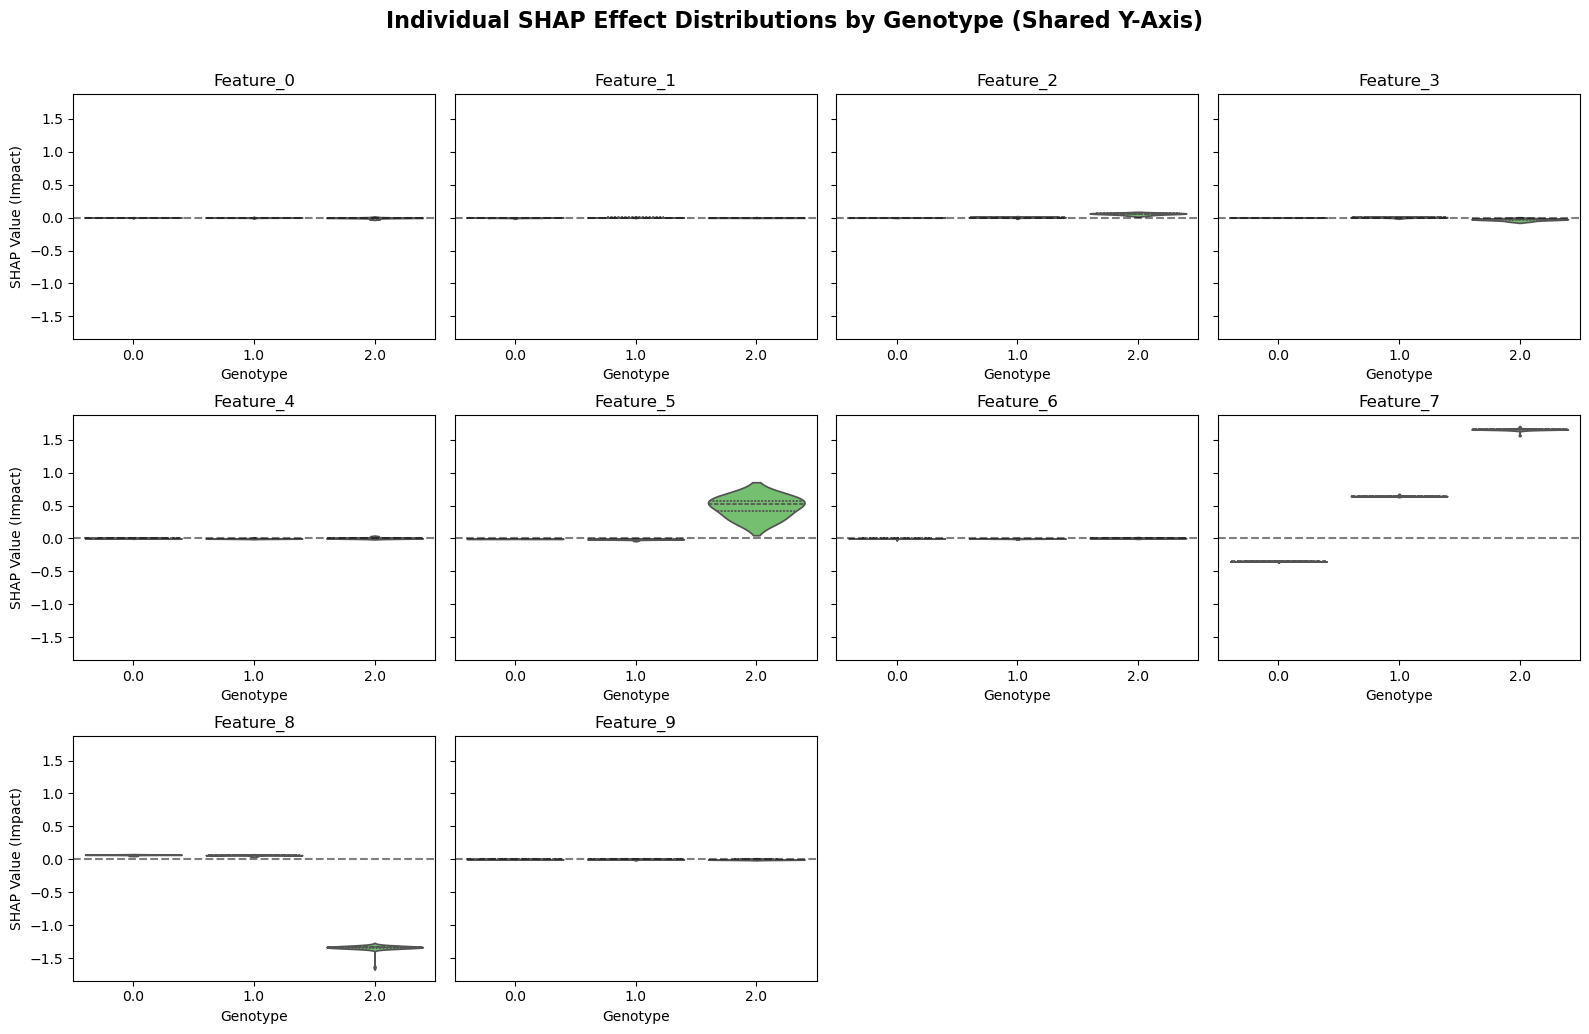

In [9]:

# 7. Individual Feature Violin Plots (All in one grid)
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we shouldn't see any


--- Computing SHAP Interaction Values (this may take a moment) ---


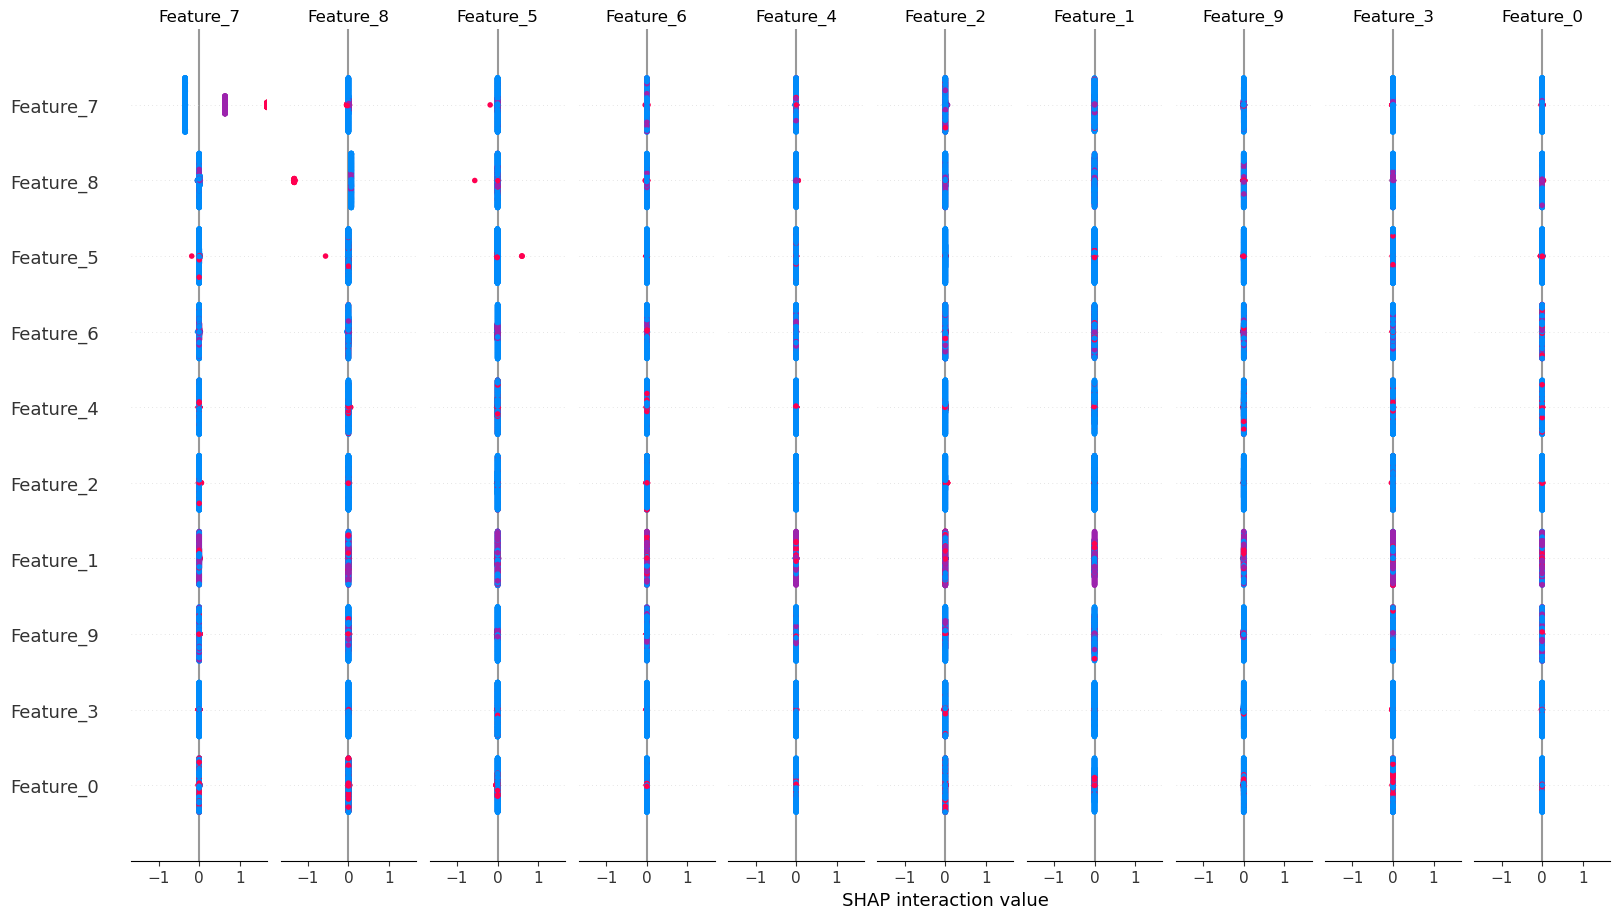


Strongest Interaction found by SHAP: Feature_7 & Feature_8
Plotting pure interaction effect for Feature_7 and Feature_8...


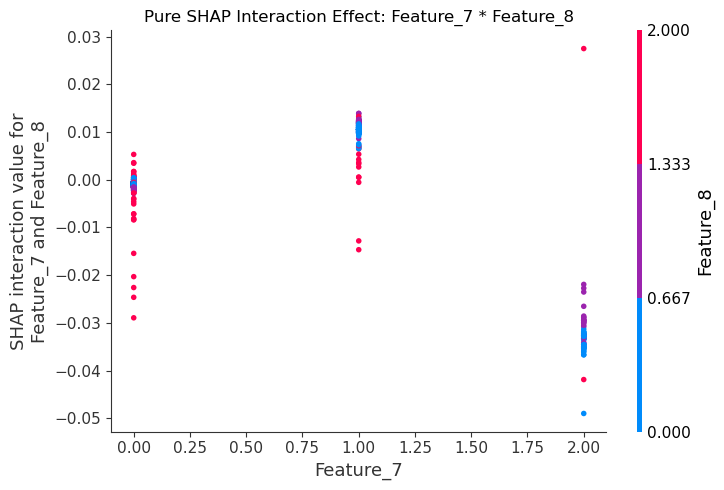

In [10]:

# 8. Deep Dive: Interactions
analyze_shap_interactions(model, X_test_cat)


#### SHAP summry

In [11]:

# Print numerical ranking and save the list!
ranked_features = print_feature_importance(shap_values)



--- SHAP Feature Importance Ranking ---
SHAP Global Importance Dictionary:
  Feature_7: 0.5051
  Feature_8: 0.1433
  Feature_5: 0.0069
  Feature_6: 0.0019
  Feature_4: 0.0016
  Feature_2: 0.0016
  Feature_1: 0.0016
  Feature_9: 0.0013
  Feature_3: 0.0011
  Feature_0: 0.0010

Ranked Features (Most to Least Important):
['Feature_7', 'Feature_8', 'Feature_5', 'Feature_6', 'Feature_4', 'Feature_2', 'Feature_1', 'Feature_9', 'Feature_3', 'Feature_0']
---------------------------------------



## test for linear combination with some feature interactions

### make example data 2

In [12]:
# 1. Generate Data
X, _, y, visible_features, _ = generate_synthetic_data_with_hidden_features(
    num_inputs=10, 
    num_samples=5000, 
    num_contributing_features=(3, 5), 
    num_hidden_features=(0, 0), 
    weight_range=(-3, 3), 
    num_interactions=(2, 3), 
    interaction_weight_range=(-3, 3), 
    noise_std=0.1, 
    hidden_in_linear=False,           
    hidden_in_interactions=False,
)
# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Generative Model Info (With HIDDEN Features) ---
y = 
  (2.83 * Feature_7 [additive]) + 
  (-2.44 * Feature_9 [additive]) + 
  (1.02 * Feature_0 [additive]) + 
  (-0.96 * Feature_5 [recessive]) + 
  (-2.29 * (Feature_3, Feature_9) [xor_interference]) + 
  (-1.32 * (Feature_1, Feature_4) [xor_interference]) + 
  (1.02 * (Feature_0, Feature_1) [multiplicative]) 
  + Noise(0, 0.1)



### make the Traditional Baseline (OLS)


--- Traditional Regression Analysis (OLS) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                     4451.
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:28:33   Log-Likelihood:                -4705.5
No. Observations:                4000   AIC:                             9433.
Df Residuals:                    3989   BIC:                             9502.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

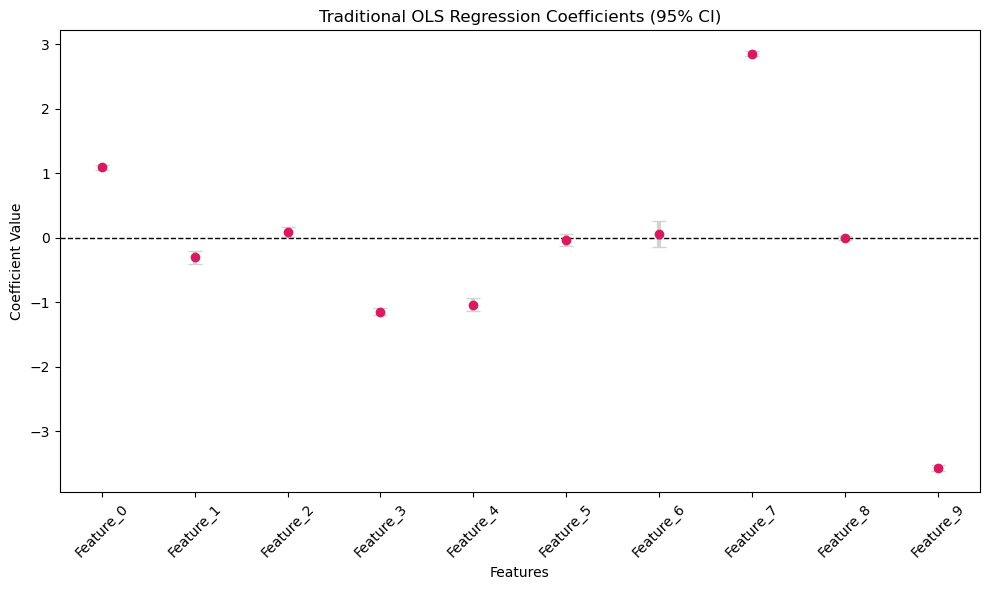

In [13]:

# 2. Traditional Baseline (OLS)
perform_traditional_regression(X_train, y_train)


### make a simple xgboost model for test 2

In [14]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost)
model = xgb.XGBRegressor(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1 Evaluation & XGBoost Importances
evaluate_xgb_model(model, X_test_cat, y_test)

--- XGBoost Performance (Testing) ---
R2 Score: 0.9974
MSE: 0.0164



### look at XGBoost Native Importances

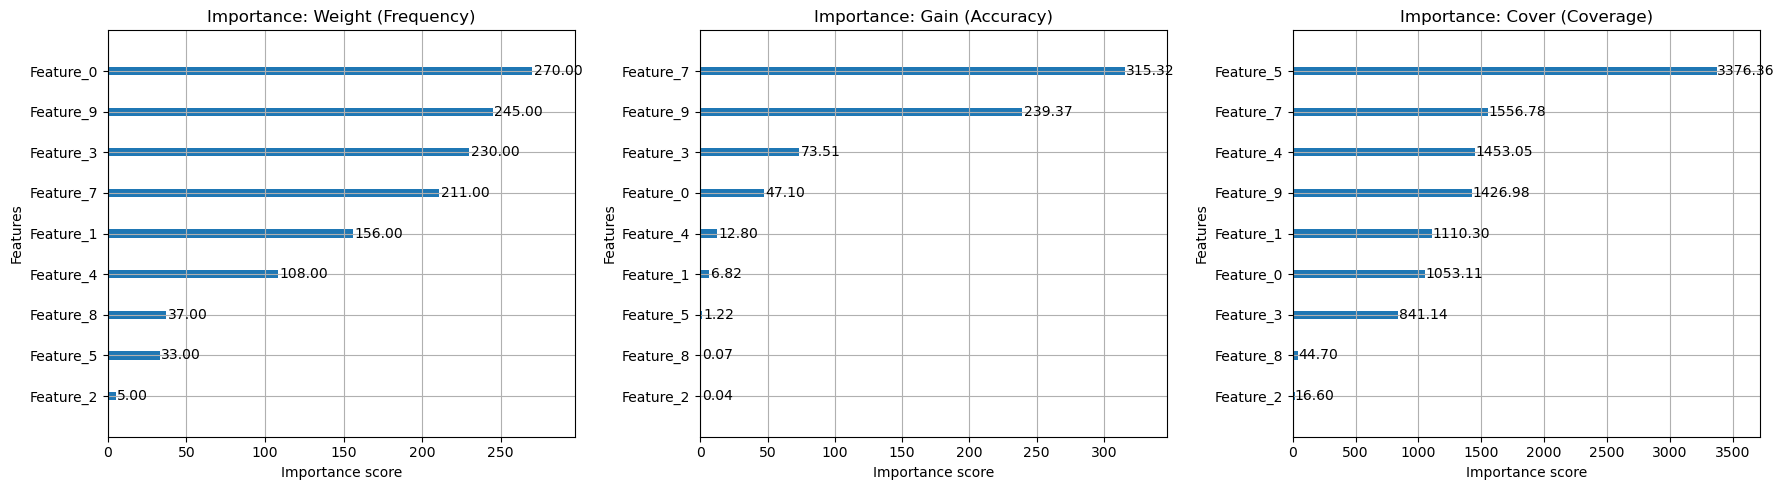

In [15]:

# 5.2 XGBoost Importances
plot_all_xgb_importances(model)


### try to use SHAP to find the influencing inputs

In [16]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

In [17]:

# Print numerical ranking
print_feature_importance(shap_values)



--- SHAP Feature Importance Ranking ---
SHAP Global Importance Dictionary:
  Feature_7: 1.4205
  Feature_9: 1.2486
  Feature_0: 0.6806
  Feature_3: 0.4982
  Feature_4: 0.0976
  Feature_1: 0.0544
  Feature_5: 0.0063
  Feature_8: 0.0007
  Feature_2: 0.0000
  Feature_6: 0.0000

Ranked Features (Most to Least Important):
['Feature_7', 'Feature_9', 'Feature_0', 'Feature_3', 'Feature_4', 'Feature_1', 'Feature_5', 'Feature_8', 'Feature_2', 'Feature_6']
---------------------------------------



['Feature_7',
 'Feature_9',
 'Feature_0',
 'Feature_3',
 'Feature_4',
 'Feature_1',
 'Feature_5',
 'Feature_8',
 'Feature_2',
 'Feature_6']

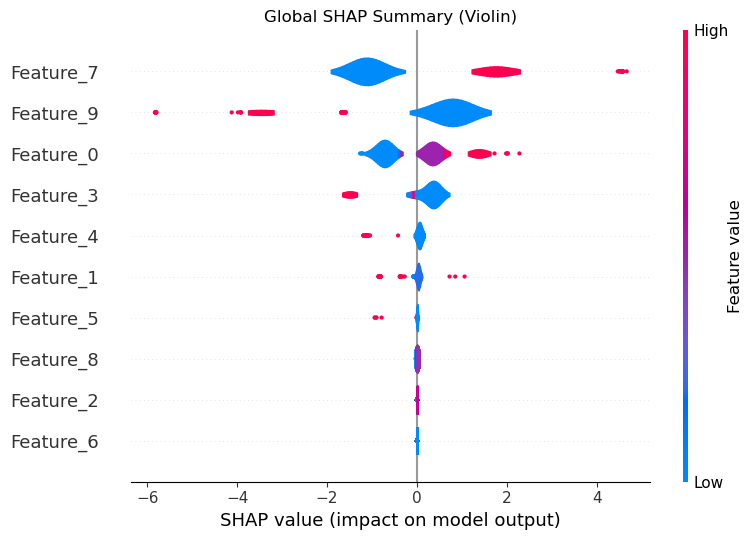

In [18]:

# Global SHAP Violin Summary
plot_shap_summary_violin(shap_values, X_test_cat)


Generating SHAP violin grid for all features...


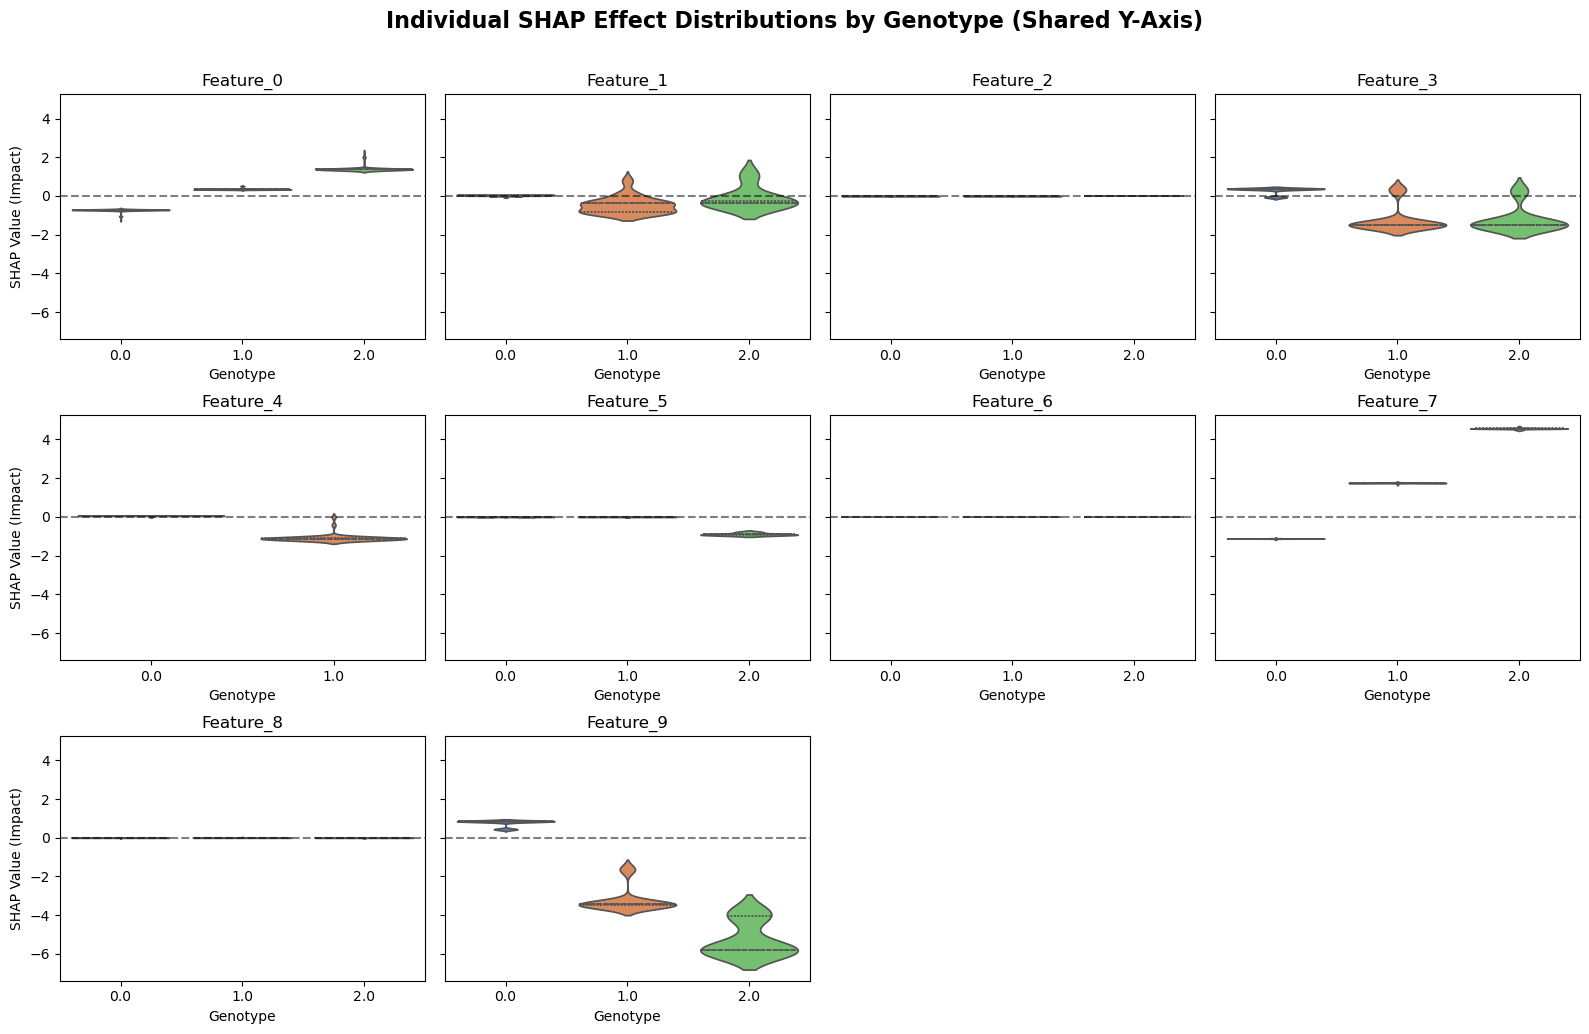

In [19]:

# 7. Individual Feature Violin Plots (All in one grid)
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we shouldn't see any


--- Computing SHAP Interaction Values (this may take a moment) ---


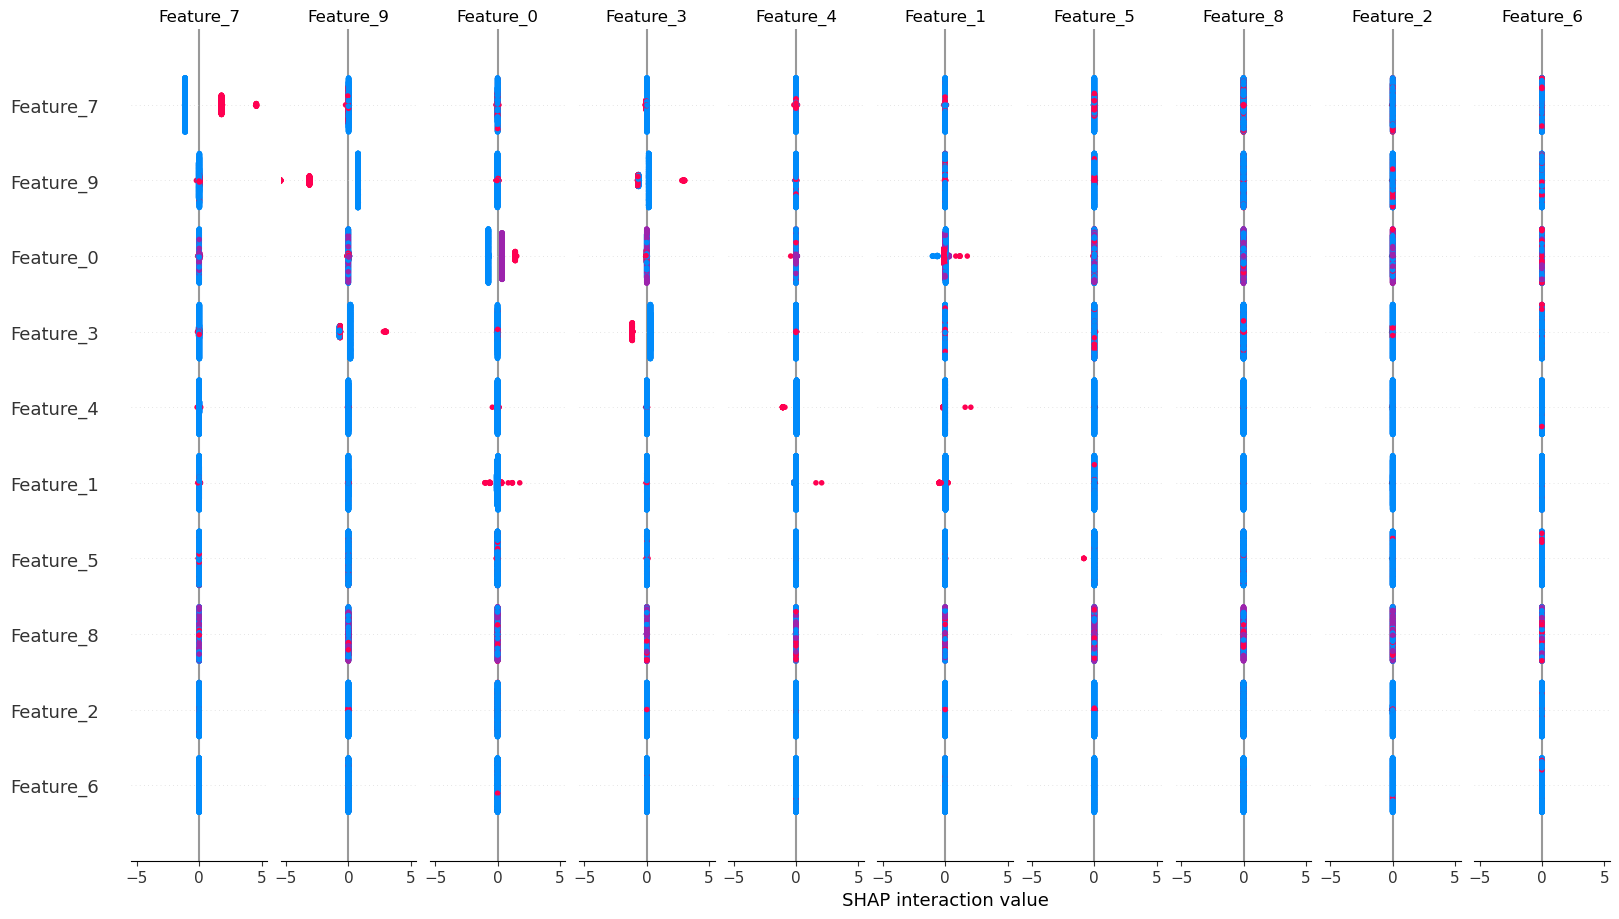


Strongest Interaction found by SHAP: Feature_9 & Feature_3
Plotting pure interaction effect for Feature_9 and Feature_3...


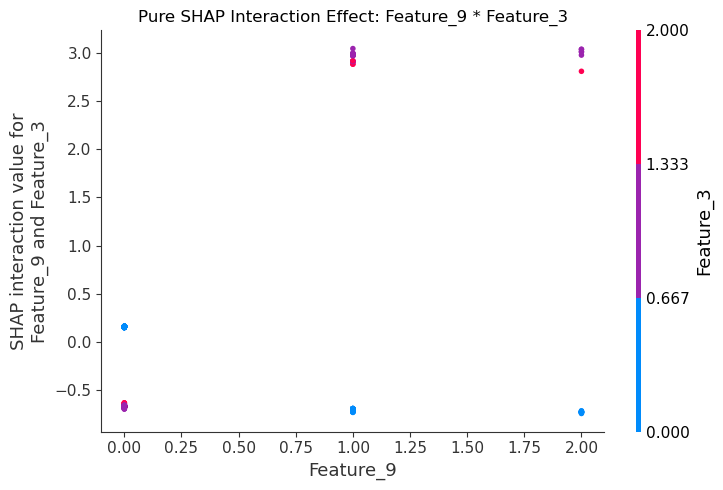

In [20]:

# 8. Deep Dive: Interactions
analyze_shap_interactions(model, X_test_cat)


#### SHAP summry

In [21]:

# Print numerical ranking and save the list!
ranked_features = print_feature_importance(shap_values)



--- SHAP Feature Importance Ranking ---
SHAP Global Importance Dictionary:
  Feature_7: 1.4205
  Feature_9: 1.2486
  Feature_0: 0.6806
  Feature_3: 0.4982
  Feature_4: 0.0976
  Feature_1: 0.0544
  Feature_5: 0.0063
  Feature_8: 0.0007
  Feature_2: 0.0000
  Feature_6: 0.0000

Ranked Features (Most to Least Important):
['Feature_7', 'Feature_9', 'Feature_0', 'Feature_3', 'Feature_4', 'Feature_1', 'Feature_5', 'Feature_8', 'Feature_2', 'Feature_6']
---------------------------------------



## test for addition of hidden features

### make example data 3

In [22]:
# 1. Generate Data
X, X_hidden, y, visible_features, hidden_features = generate_synthetic_data_with_hidden_features(
    num_inputs=10, 
    num_samples=5000, 
    num_contributing_features=(3, 5), 
    num_hidden_features=(1, 2), 
    weight_range=(-3, 3), 
    num_interactions=(2, 3), 
    interaction_weight_range=(-3, 3), 
    noise_std=0.1, 
    hidden_in_linear=True,           
    hidden_in_interactions=True
)
# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Generative Model Info (With HIDDEN Features) ---
y = 
  (2.83 * Feature_3 [dominant]) + 
  (-2.20 * Feature_9 [recessive]) + 
  (-2.00 * Feature_7 [additive]) + 
  (1.96 * Feature_8 [recessive]) + 
  (0.54 * Hidden_0 [recessive]) + 
  (-0.51 * Feature_5 [dominant]) + 
  (-1.53 * (Feature_6, Hidden_0) [multiplicative]) + 
  (1.03 * (Feature_6, Feature_9) [dominant_epistasis]) 
  + Noise(0, 0.1)



### make the Traditional Baseline (OLS)


--- Traditional Regression Analysis (OLS) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     1785.
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:28:44   Log-Likelihood:                -5295.2
No. Observations:                4000   AIC:                         1.061e+04
Df Residuals:                    3989   BIC:                         1.068e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

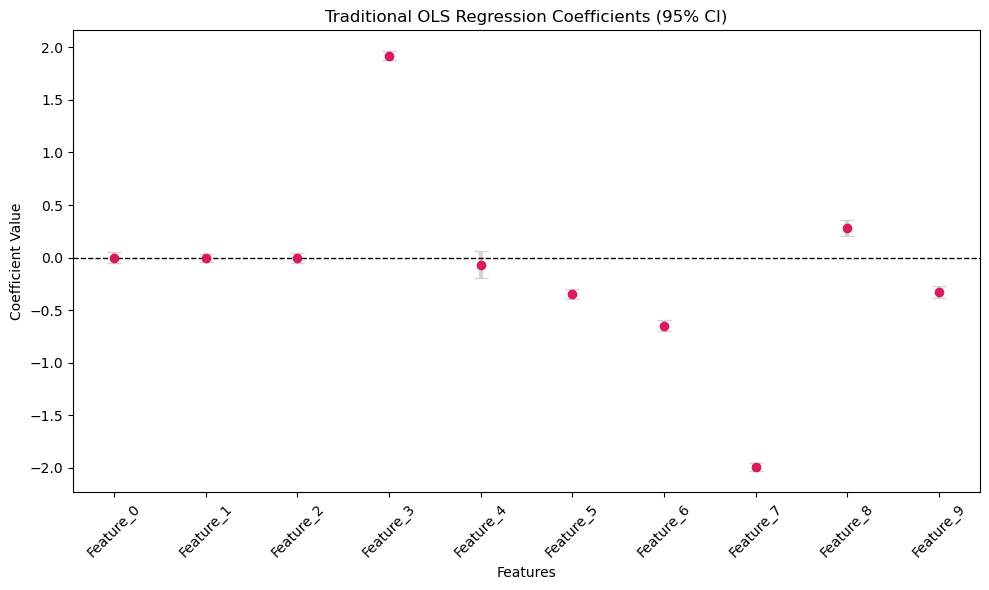

In [23]:

# 2. Traditional Baseline (OLS)
perform_traditional_regression(X_train, y_train)


### make a simple xgboost model for test 3

In [24]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost)
model = xgb.XGBRegressor(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1 Evaluation & XGBoost Importances
evaluate_xgb_model(model, X_test_cat, y_test)

--- XGBoost Performance (Testing) ---
R2 Score: 0.9133
MSE: 0.3933



### look at XGBoost Native Importances

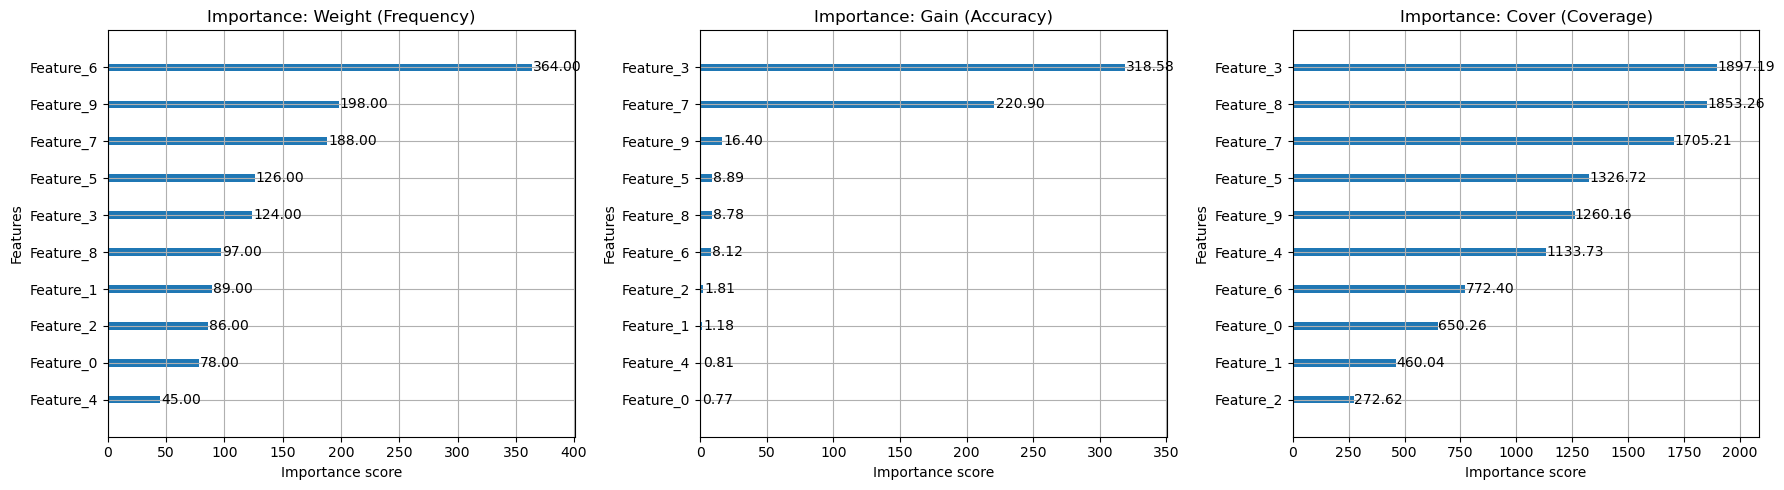

In [25]:

# 5.2 XGBoost Importances
plot_all_xgb_importances(model)


### try to use SHAP to find the influencing inputs

In [26]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

In [27]:

# Print numerical ranking
print_feature_importance(shap_values)



--- SHAP Feature Importance Ranking ---
SHAP Global Importance Dictionary:
  Feature_3: 1.3423
  Feature_7: 1.2401
  Feature_6: 0.2708
  Feature_5: 0.2073
  Feature_9: 0.1265
  Feature_8: 0.0502
  Feature_1: 0.0193
  Feature_0: 0.0079
  Feature_2: 0.0062
  Feature_4: 0.0039

Ranked Features (Most to Least Important):
['Feature_3', 'Feature_7', 'Feature_6', 'Feature_5', 'Feature_9', 'Feature_8', 'Feature_1', 'Feature_0', 'Feature_2', 'Feature_4']
---------------------------------------



['Feature_3',
 'Feature_7',
 'Feature_6',
 'Feature_5',
 'Feature_9',
 'Feature_8',
 'Feature_1',
 'Feature_0',
 'Feature_2',
 'Feature_4']

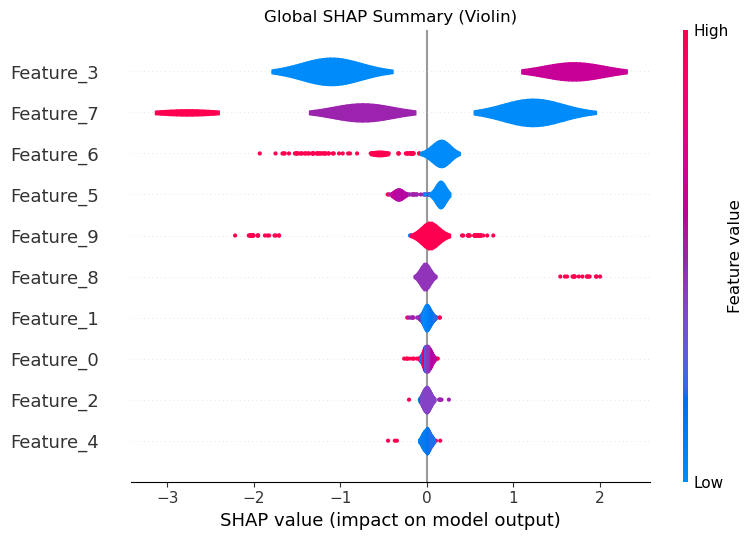

In [28]:

# Global SHAP Violin Summary
plot_shap_summary_violin(shap_values, X_test_cat)


Generating SHAP violin grid for all features...


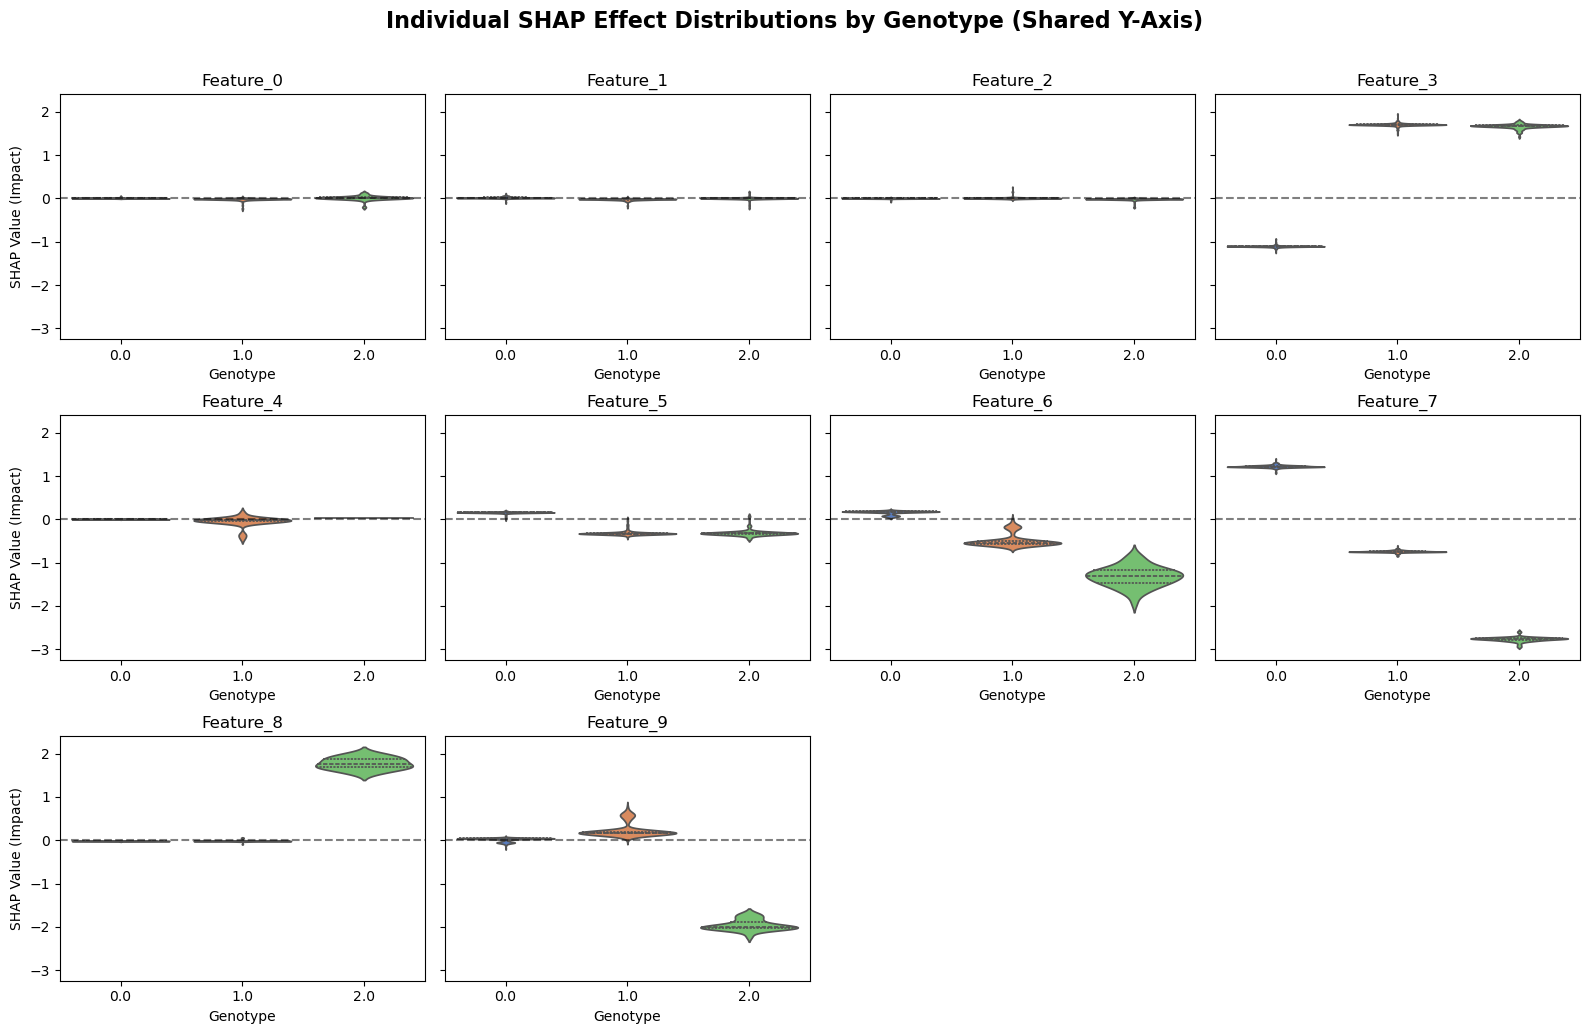

In [29]:

# 7. Individual Feature Violin Plots (All in one grid)
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we shouldn't see any


--- Computing SHAP Interaction Values (this may take a moment) ---


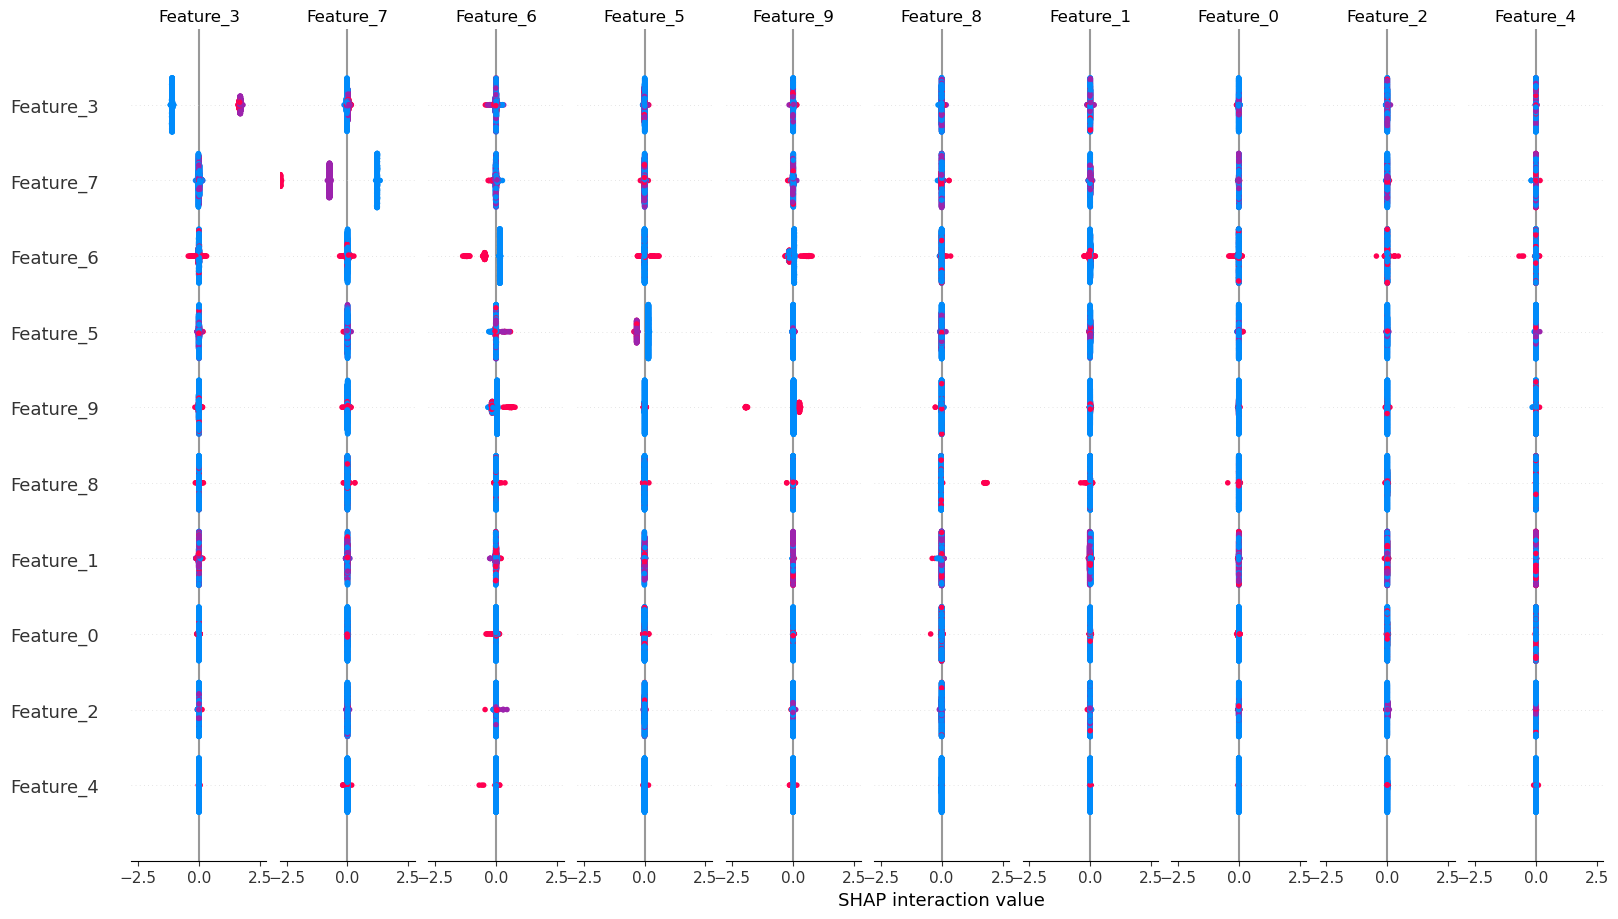


Strongest Interaction found by SHAP: Feature_9 & Feature_6
Plotting pure interaction effect for Feature_9 and Feature_6...


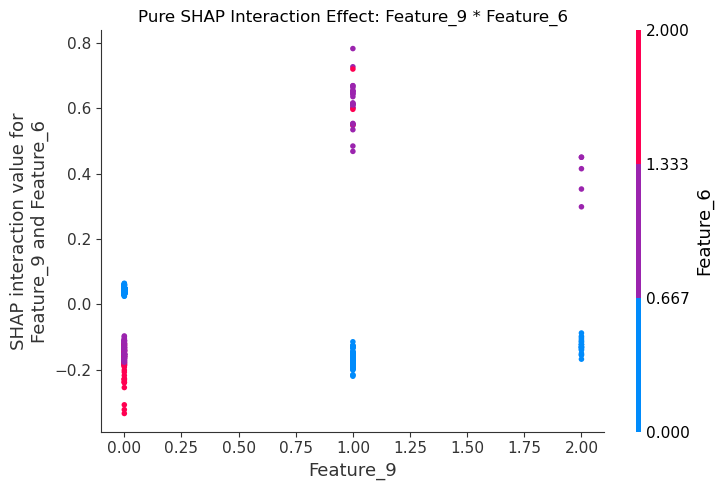

In [30]:

# 8. Deep Dive: Interactions
analyze_shap_interactions(model, X_test_cat)


#### SHAP summry

In [31]:

# Print numerical ranking and save the list!
ranked_features = print_feature_importance(shap_values)



--- SHAP Feature Importance Ranking ---
SHAP Global Importance Dictionary:
  Feature_3: 1.3423
  Feature_7: 1.2401
  Feature_6: 0.2708
  Feature_5: 0.2073
  Feature_9: 0.1265
  Feature_8: 0.0502
  Feature_1: 0.0193
  Feature_0: 0.0079
  Feature_2: 0.0062
  Feature_4: 0.0039

Ranked Features (Most to Least Important):
['Feature_3', 'Feature_7', 'Feature_6', 'Feature_5', 'Feature_9', 'Feature_8', 'Feature_1', 'Feature_0', 'Feature_2', 'Feature_4']
---------------------------------------

